# L08 Segmentation I

In [1]:
from holoviews.examples.reference.elements.bokeh.TriMesh import min_radius
!wget 'https://drive.google.com/uc?id=1Ku89NM5rj6O3POXLT8vlhh6xDv5AHqXG' -O ca
!wget 'https://drive.google.com/uc?id=1ZAdq_5_Tck7h2ruGExn-8FVB1y3Ox0DE' -O 2lines.png
!wget 'https://drive.google.com/uc?id=1H3sk8nqoePFTDQd0e1CqBQ3_GvfYFXpM' -O bacteria.png
!wget 'https://drive.google.com/uc?id=1Y9yB011V9H4TwYn2kp0CUAbXsIb8rMbS' -O circle.png
!wget 'https://drive.google.com/uc?id=1DesK4q3LLaRLDi5viU-3c0C-vy8fjh1A' -O circuit1.PNG
!wget 'https://drive.google.com/uc?id=1Ku89NM5rj6O3POXLT8vlhh6xDv5AHqXG' -O cameraman.tif
!wget 'https://drive.google.com/uc?id=1QQFMlY8Ds4D7-AUh_g-WqWhZhiAQFwMc' -O clock2.jpg
!wget 'https://drive.google.com/uc?id=1KSPV-8X8HtNHfFF4RlT_t_hn5Trfl6K4' -O coins.jpg
!wget 'https://drive.google.com/uc?id=1jFTYRxlNDfxA0o5NIkQr97dt7b-2DmRa' -O findLine2.png
!wget 'https://drive.google.com/uc?id=12szRAjUEPWbLf_vfpItbcdBf5VAZOfz1' -O findLines.png
!wget 'https://drive.google.com/uc?id=16YXK8gHT5Sj0Tc0ggnzdbIl_sh49PHDd' -O home_cropped.jpg

--2025-10-05 16:00:57--  https://drive.google.com/uc?id=1Ku89NM5rj6O3POXLT8vlhh6xDv5AHqXG
Resolving drive.google.com (drive.google.com)... 2404:6800:4001:80c::200e, 172.217.25.238, 172.217.25.238, ...
Connecting to drive.google.com (drive.google.com)|2404:6800:4001:80c::200e|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Ku89NM5rj6O3POXLT8vlhh6xDv5AHqXG [following]
--2025-10-05 16:00:58--  https://drive.usercontent.google.com/download?id=1Ku89NM5rj6O3POXLT8vlhh6xDv5AHqXG
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 2404:6800:4001:814::2001, 172.217.25.33
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|2404:6800:4001:814::2001|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 38783 (38K) [image/png]
Saving to: ‘ca’

ca                  100%[===================>]  37.87K  --.-KB/s    in 0.09s   

2025-10-05 16:01:00 (416 KB/s)

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from scipy import signal
from scipy.ndimage import gaussian_filter

## Edge detection
* Sobel : https://docs.opencv.org/3.4/d4/d86/group__imgproc__filter.html#gacea54f142e81b6758cb6f375ce782c8d
* Canny : https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html

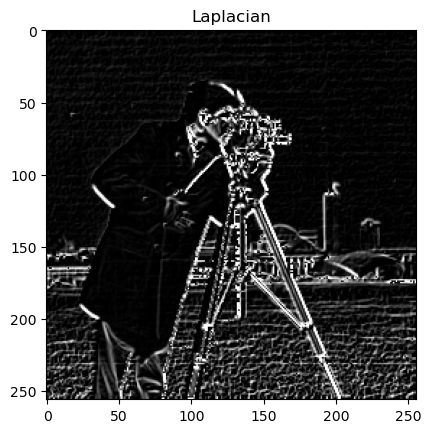

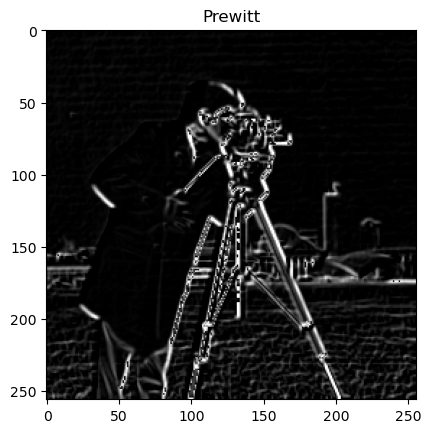

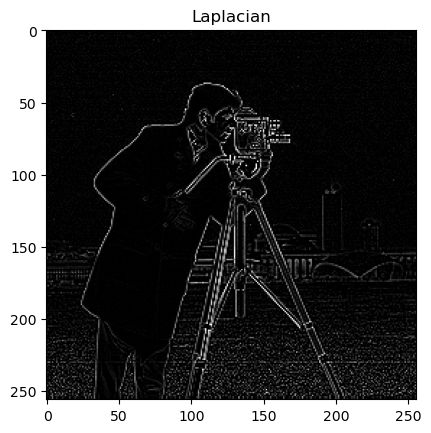

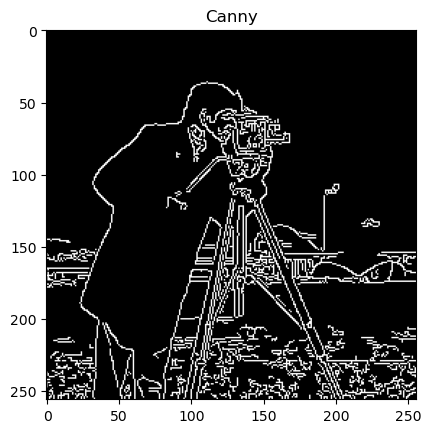

In [10]:
img = cv2.imread('cameraman.tif', cv2.IMREAD_GRAYSCALE)
img_gaussian_blur = cv2.GaussianBlur(img, (3, 3), 0)

# sobel
img_sobelx = cv2.Sobel(img, cv2.CV_8U, 1, 0, ksize=3)
img_sobely = cv2.Sobel(img, cv2.CV_8U, 0, 1, ksize=3)
img_sobel = abs(img_sobelx) + abs(img_sobely)
plt.imshow(img_sobel, cmap="gray")
plt.title("Laplacian")
plt.show()

# prewitt
kernelx = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

img_prewittx = cv2.filter2D(img_gaussian_blur, -1, kernelx)
img_prewitty = cv2.filter2D(img_gaussian_blur, -1, kernely)
img_prewitt = img_prewittx + img_prewitty
plt.imshow(img_prewitt, cmap="gray");
plt.title("Prewitt")
plt.show()

# Laplacian
# 4-neighbor
Laplacian4 = np.array([[0, 1, 0],
                       [1, -4, 1],
                       [0, 1, 0]], dtype=np.float32)

# 8-neighbor (stronger)
Laplacian8 = np.array([[1, 1, 1],
                       [1, -8, 1],
                       [1, 1, 1]], dtype=np.float32)
img_Laplacian = cv2.filter2D(img, -1, Laplacian4)
plt.imshow(img_Laplacian, cmap="gray");
plt.title("Laplacian")
plt.show()

#canny
img_canny = cv2.Canny(img, 100, 200)
plt.imshow(img_canny, cmap="gray");
plt.title("Canny")
plt.show()


## Hough Line transform
* https://docs.opencv.org/3.4/d9/db0/tutorial_hough_lines.html

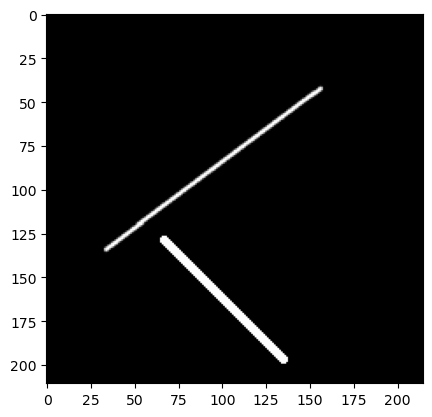

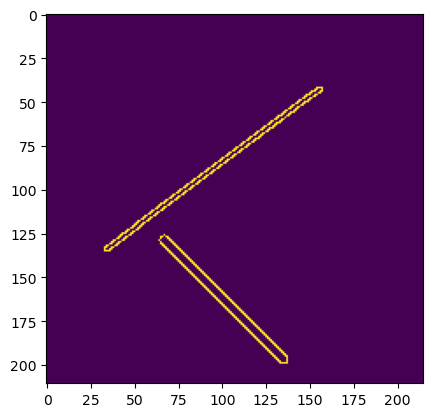

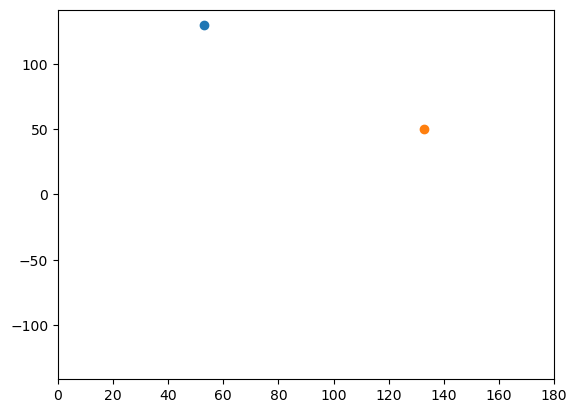

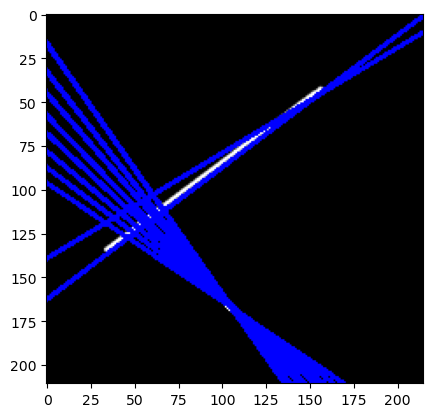

In [11]:
# HoughLines transforms
img = cv2.imread('2lines.png')
plt.imshow(img)
plt.show()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)
plt.imshow(edges)
plt.show()
lines = cv2.HoughLines(edges, 10, np.pi / 180, 100)

# # Convert radian to degree
linesdegree = lines.copy()
linesdegree[:, 0:1, 1:2] = linesdegree[:, 0:1, 1:2] * 180 / np.pi

# # use scatter plot
for i in range(0, 2):  #len(linesdegree)):
    plt.scatter(linesdegree[i, 0:1, 1:2], linesdegree[i, 0:1, 0:1])

# # set x,y limits
plt.xlim(0, 180)
plt.ylim(-100 * np.sqrt(2), 100 * np.sqrt(2))
plt.show()

# Draw the detected line on the image
for line in lines[:10]:
    rho, theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))

    cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
plt.imshow(img)
plt.show()

### Exercise #1 Use Hough Line transform to find the clock hands

In [64]:
linesdegree[:, 0:1]

array([[[ 60.]],

       [[120.]],

       [[ 60.]],

       ...,

       [[165.]],

       [[166.]],

       [[166.]]], shape=(2215, 1, 1), dtype=float32)

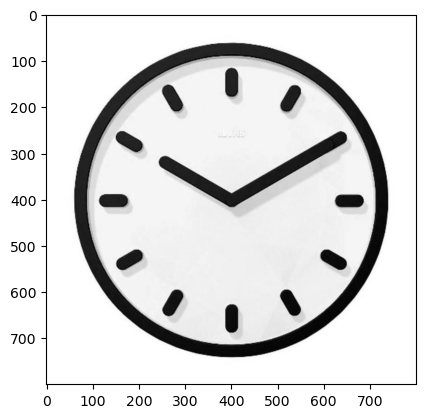

[[[555.          1.0471976]]

 [[155.          2.0943952]]

 [[535.          1.0471976]]]


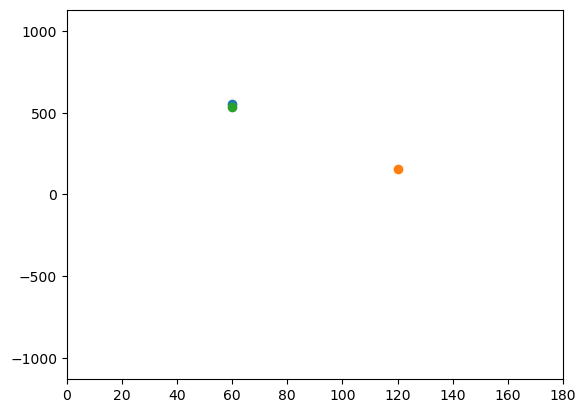

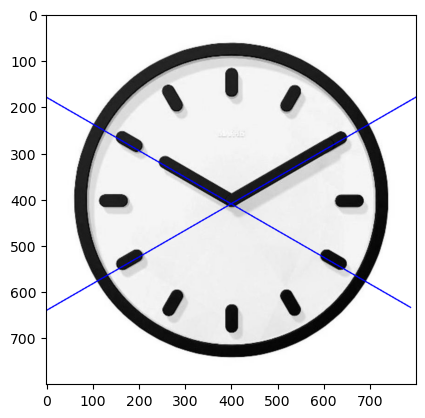

In [75]:
img = cv2.imread('clock2.jpg')
plt.imshow(img)
plt.show()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
m, n = gray.shape
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

# TO DO #1: Try to customize Hough Line parameters
lines = cv2.HoughLines(edges, 10, np.pi / 180, 500)
print(lines)
# # Convert radian to degree
linesdegree = lines.copy()
linesdegree[:, 0:1, 1:2] = linesdegree[:, 0:1, 1:2] * 180 / np.pi

# # use scatter plot
for i in range(0, len(linesdegree)):
    plt.scatter(linesdegree[i, 0:1, 1:2], linesdegree[i, 0:1, 0:1])

# # set x,y limits
plt.xlim(0, 180)
plt.ylim(-m * np.sqrt(2), m * np.sqrt(2))
plt.show()

# TO DO #2: Draw the detected line on the image
for line in lines[:2]:
    rho, theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))

    cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
plt.imshow(img)
plt.show()


### Exercise #2 Use Hough Circle to find the circle of the clock
* https://docs.opencv.org/4.x/da/d53/tutorial_py_houghcircles.html

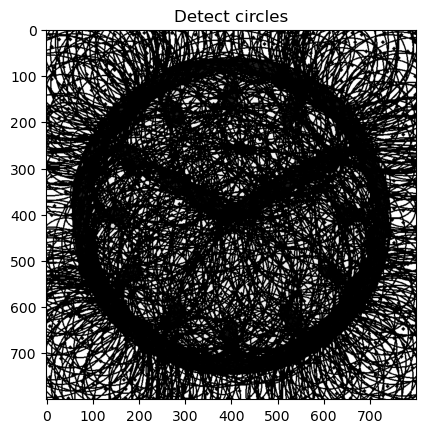

In [49]:
img = cv2.imread('clock2.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 50, 150, apertureSize=3)
# TO DO: Use Hough Circle to find the circle of the clock & adjust the parameters
circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, 1, 20,
                           param1=20, param2=100, minRadius=5, maxRadius=0)

circles = np.uint16(np.around(circles))
for i in circles[0,:]:
    # draw the outer circle
    cv2.circle(gray,(i[0],i[1]),i[2],(0,255,0),2)
    # draw the center of the circle
    cv2.circle(gray,(i[0],i[1]),2,(0,0,255),3)

plt.title("Detect circles")
plt.imshow(gray, cmap="gray")
# cv2.imshow('detected circles',gray)

## Threshold

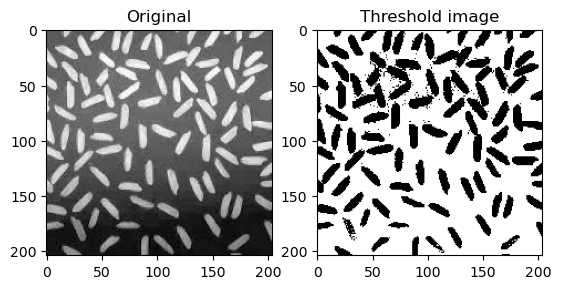

In [54]:
img = cv2.imread("bacteria.png", 0)
ret, thresh1 = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY_INV)

plt.subplot(1, 2, 1), plt.imshow(img, 'gray')
plt.title("Original")
plt.subplot(1, 2, 2), plt.imshow(thresh1, 'gray')
plt.title("Threshold image")
plt.show()

# TO DO: Choose the threshold that best segments the bacteria from your own perspective
ret, thresh1 = cv2.threshold(img, 1.0, 255, cv2.THRESH_BINARY)


* Adaptive Threshold

In [ ]:
img = cv2.imread("bacteria.png", 0)
th2 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, \
                            cv2.THRESH_BINARY, 21, 0)
th3 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, \
                            cv2.THRESH_BINARY, 21, 0)

plt.imshow(th2, cmap='gray')
plt.show()

plt.imshow(th3, cmap='gray')
plt.show()

## Optimal Threshold
* See what is the output threshold selected by Otsu's thresholding
* https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html

img = cv2.imread("bacteria.png",0)

ret,thresh1 = cv2.threshold(img,0,255,cv2.THRESH_OTSU | cv2.THRESH_BINARY)

plt.imshow(thresh1,cmap='gray')
plt.title("optimal th = " + str(ret))
plt.show()

## Region Growing
* https://docs.opencv.org/4.x/d3/db4/tutorial_py_watershed.html

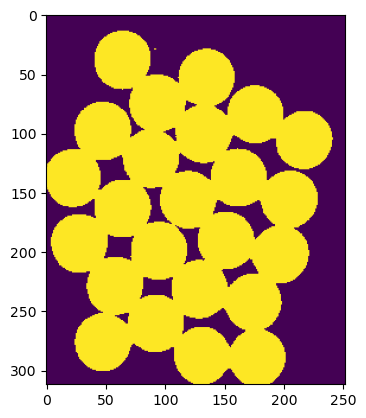

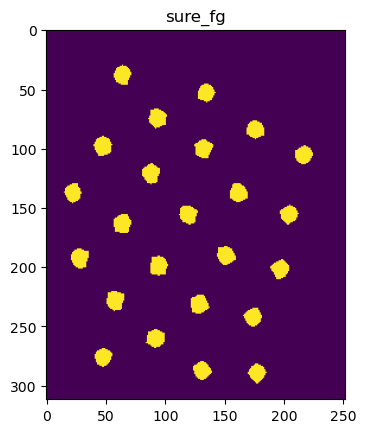

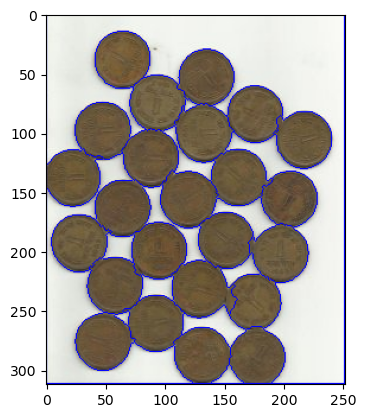

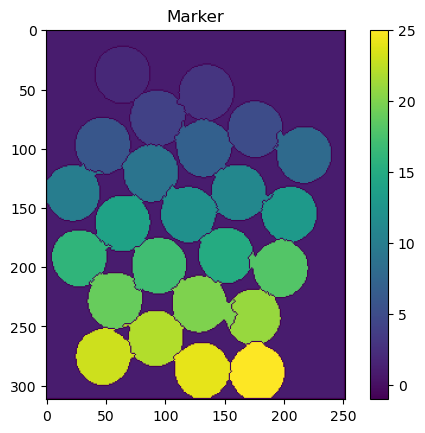

In [8]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('coins.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(thresh);
plt.show()

# Finding sure foreground area
dist_transform = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, cv2.THRESH_BINARY)
plt.imshow(sure_fg);
plt.title("sure_fg");
plt.show()
# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(thresh, sure_fg)

# Marker labelling
ret, markers = cv2.connectedComponents(sure_fg)
# Add one to all labels so that sure background is not 0, but 1
markers = markers + 1
# Now, mark the region of unknown with zero
markers[unknown == 255] = 0

markers = cv2.watershed(img, markers)
img[markers == -1] = [255, 0, 0]  # BGR

plt.imshow(img[:, :, ::-1]);
plt.show()
plt.imshow(markers);
plt.colorbar();
plt.title("Marker");
plt.show()